### 인공신경망

In [ ]:
## 연산 만들기

import tensorflow as tf

a = [0,0,1,1]
b = [0,1,0,1]

res = tf.transpose(tf.constant([a,b],dtype=tf.float32))
#res

'''
a, b 를 넣어서 res_and는 결과가 [0,0,0,1] 되는 거야  ==> 학습

res_and 의 연산결과  [0,0,0,1] 
'''


## 정답지 역할
res_and = tf.constant([0,0,0,1], dtype=tf.float32)
res_or = tf.constant([0,1,1,1], dtype=tf.float32)
res_xor = tf.constant([0,1,1,0], dtype=tf.float32)

print(f"and : {res_and} , or : {res_or} , xor : {res_xor}")


and : [0. 0. 0. 1.] , or : [0. 1. 1. 1.] , xor : [0. 1. 1. 0.]


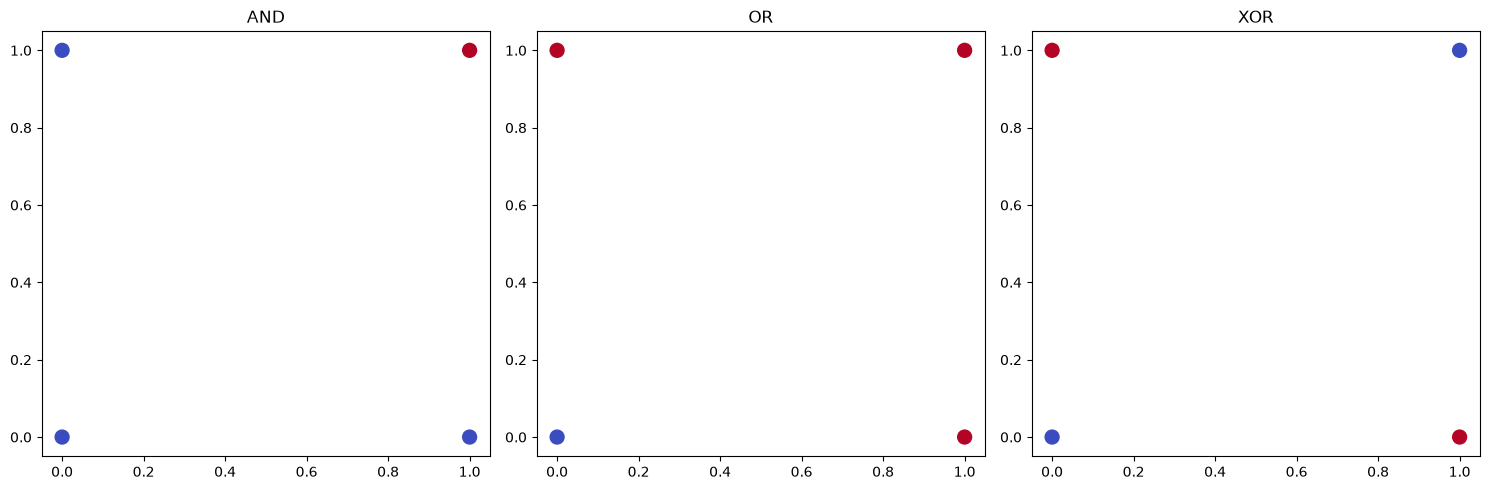

In [9]:
### 위에서 만든 연산으로 계산해보기
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,3, figsize=(15,5))

## AND
axes[0].scatter(res[:,0],res[:,1], c=res_and, cmap='coolwarm',s=100)
axes[0].set_title("AND")

## OR
axes[1].scatter(res[:,0],res[:,1], c=res_or, cmap='coolwarm',s=100)
axes[1].set_title("OR")

## XOR
axes[2].scatter(res[:,0],res[:,1], c=res_xor, cmap='coolwarm',s=100)
axes[2].set_title("XOR")


plt.tight_layout()
plt.show()

퍼셉트론

In [ ]:
### 단일 퍼셉트론
##  hidden layer 가 없음

'''
입력층 (2개)
   |
   v
출력층 (1개)


반복
------------------------------
입력데이터
    |
    V
레이어 계산(가중치, 편향)
    |
    V
활성화 함수 (sigmoid)
    |
    V
예측값 생성  : 0,1  
    |
    V
손실함수 계산 : binary_crossentropy
    |
    V
역전파(코드에 없음 : 실행시 내부자동실행)- 누가 잘못했는가?    
    |
    V
경사하강법 :  SGD - 가중치 변경 정도
    |
    V
가중치 수정   
---------------------------------    
'''



#1. 모델 생성
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(1, input_dim=2, activation='sigmoid')
    ## layers.Dense : 
    #  1 : 출력 뉴런 1개 생성
    # input_dim=2 : 입력 특성 2개
    # activation='sigmoid' : 활성화함수   -- sigmoid : 이진분류(0,1로 구분)
                        ## 문제를 풀어서 정답을 작성
])


#2. 학습설정 - 위에서 만든 model에 학습을 설정한다
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=1.0),  ## 경사하강법 : 
                                                        ##오차발생 -> 가중치 수정 필요 -> 수정하는 방법    
    loss = 'binary_crossentropy' ,          ## 이진 분류용 손실함수 : 예측 0~1
    metrics=['accuracy']                    ##학습중 정확도 출력
)



### 3. 학습

model.fit(
    res,                ##입력데이터
    res_and,            ##정답데이터
    epochs=100,         ## 전체 반복 횟수
    batch_size=4        ## 한번에 사용할 데이터수
)

## 모델평가
loss, accuracy = model.evaluate(res, res_and)
print(f"Loss: {loss}, Accuracy:{accuracy}")

## 예측
predicitions = model.predict(res)
print(f"predicitions : {predicitions}")


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.7500 - loss: 0.8745
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7500 - loss: 0.8270
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7500 - loss: 0.7851
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7500 - loss: 0.7478
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7500 - loss: 0.7141
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7500 - loss: 0.6833
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7500 - loss: 0.6551
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7500 - loss: 0.6290
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7500 - loss: 0.6049
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7500 - loss: 0.5825
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7500 - loss: 0.5617
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7500 - l

### 다중 퍼셉트론

In [17]:
'''
입력 2개
    |
    v
은닉층 Dense(16) 
    |   ReLU
    v
출력층 (1개)
    |   Sigmoid
    v
출력
'''




#1. 모델 생성
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(16, input_dim=2, activation='relu'),  ## 은닉층(추가됨)
                                                    ##relu : 꺽인 비선형모델
    tf.keras.layers.Dense(1,activation='sigmoid'),              ## 출력층
])


#2. 학습설정 - 위에서 만든 model에 학습을 설정한다
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=1.0),    
    loss = 'binary_crossentropy' ,       
    metrics=['accuracy']                  
)



### 3. 학습

model.fit(
    res,                ##입력데이터
    res_and,            ##정답데이터
    epochs=100,         ## 전체 반복 횟수
    batch_size=4        ## 한번에 사용할 데이터수
)

## 모델평가
loss, accuracy = model.evaluate(res, res_and)
print(f"Loss: {loss}, Accuracy:{accuracy}")

## 예측
predicitions = model.predict(res)
print(f"predicitions : {predicitions}")


Epoch 1/100


c:\Users\lee\miniconda3\envs\efgenv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.7500 - loss: 0.6806
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7500 - loss: 0.6184
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7500 - loss: 0.5657
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7500 - loss: 0.5259
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7500 - loss: 0.4883
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7500 - loss: 0.4577
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7500 - loss: 0.4233
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 1.0000 - loss: 0.3903
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 1.0000 - loss: 0.3637
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 1.0000 - loss: 0.3275
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 1.0000 - loss: 0.3052
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 1.0000 - loss: 0.2715
